# 1. PROJECT CONTEXT

## Research Title
**"Analisis Performa Algoritma Machine Learning untuk Klasifikasi Jenis dan Tingkat Keparahan Cyberbullying pada Teks Bahasa Indonesia Menggunakan TF-IDF"**
*(Performance Analysis of Machine Learning Algorithms for Cyberbullying Type and Severity Classification in Indonesian Text Using TF-IDF)*

## The Role of EDA
Exploratory Data Analysis (EDA) is performed to deeply understand the structural integrity, distributions, and characteristics of the merged dataset **before** making decisions about relabeling and validation. 

**Important:** The merged dataset must **not** be modified during EDA. Any transformations or metrics calculated here (like word counts) are strictly temporary features for analytical purposes. Real text preprocessing and cleaning belong to later stages.

# 2. EDA OBJECTIVES

This notebook aims to:
- Understand the dataset structure and data types.
- Assess data quality (missing values, duplicates, formatting inconsistencies).
- Understand the target label distributions (type and severity).
- Identify class imbalance.
- Analyze text characteristics (length, word counts).
- Identify suspicious records or anomalies.
- Generate evidence-based insights to support the research report and guide the subsequent relabeling/validation stages.

In [1]:
# 3. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import seaborn as sns
import pathlib
import collections
import warnings
import re

warnings.filterwarnings('ignore')

# Set aesthetic style for seaborn plots
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# 4. CONFIGURATION

PROJECT_ROOT = pathlib.Path.cwd().parent
DATA_MERGED_DIR = PROJECT_ROOT / "data" / "merged"
BASE_REPORTS_DIR = PROJECT_ROOT / "reports"\nREPORTS_DIR = BASE_REPORTS_DIR / "eda"

# Create reports directory if it doesn't exist
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# The expected output from the previous merging stage
MERGED_DATA_FILENAME = "merged_cyberbullying_dataset.csv"
MERGED_DATA_PATH = DATA_MERGED_DIR / MERGED_DATA_FILENAME

# Expected Target Columns based on project requirements
TEXT_COL = "text"
TYPE_COL = "cyberbullying_type"
SEVERITY_COL = "severity_level"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Merged Data Path: {MERGED_DATA_PATH}")

Project Root: /home/zapp/Kampus/PM-NEW
Merged Data Path: /home/zapp/Kampus/PM-NEW/data/merged/merged_cyberbullying_dataset.csv


In [3]:
# 5. LOAD MERGED DATASET

if not MERGED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"The merged dataset was not found at {MERGED_DATA_PATH}. "
        "Please ensure you have successfully run 'notebooks/01_data_merging.ipynb' first."
    )

print(f"Loading merged dataset from: {MERGED_DATA_PATH}")
df = pd.read_csv(MERGED_DATA_PATH)

print(f"Dataset Shape: {df.shape}\n")

print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Loading merged dataset from: /home/zapp/Kampus/PM-NEW/data/merged/merged_cyberbullying_dataset.csv
Dataset Shape: (44017, 6)

First 5 rows:


,text,cyberbullying_type,severity_level,source_dataset,source_file,original_row_id
0,setiap orang adalah seorang gadis yang akan me...,age,NaN,cyberbullying_cleaned_indo,cyberbullying_cleaned_indo.csv,0
1,bahwa pos ab kpop stans pergi ke sekolah bersa...,age,NaN,cyberbullying_cleaned_indo,cyberbullying_cleaned_indo.csv,1
2,karena beberapa orang tidak ada yang lebih bai...,age,NaN,cyberbullying_cleaned_indo,cyberbullying_cleaned_indo.csv,2
3,bro aku pelatih jv tahun lalu di skyline dan a...,age,NaN,cyberbullying_cleaned_indo,cyberbullying_cleaned_indo.csv,3
4,wanitawanita ini benarbenar mengingatkan saya ...,age,NaN,cyberbullying_cleaned_indo,cyberbullying_cleaned_indo.csv,4



Last 5 rows:


,text,cyberbullying_type,severity_level,source_dataset,source_file,original_row_id
44012,USER jangan asal ngomong ndasmu. congor lu yg ...,hate_speech,NaN,data,data.csv,13164
44013,USER Kasur mana enak kunyuk',insult,NaN,data,data.csv,13165
44014,USER Hati hati bisu :( .g\n\nlagi bosan huft \...,normal,NaN,data,data.csv,13166
44015,USER USER USER USER Bom yang real mudah terdet...,normal,NaN,data,data.csv,13167
44016,"USER Mana situ ngasih("": itu cuma foto ya kuti...",hate_speech,NaN,data,data.csv,13168


In [4]:
# 6. DATASET OVERVIEW

print("Dataset Info:")
df.info(memory_usage='deep')

print("\nMemory Usage:")
display(df.memory_usage(deep=True))

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 44017 entries, 0 to 44016
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   text                44007 non-null  str    
 1   cyberbullying_type  44017 non-null  str    
 2   severity_level      0 non-null      float64
 3   source_dataset      44017 non-null  str    
 4   source_file         44017 non-null  str    
 5   original_row_id     44017 non-null  int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 30.4 MB

Memory Usage:


Index                      132
text                  21779791
cyberbullying_type     2556752
severity_level          352136
source_dataset         3324485
source_file            3500553
original_row_id         352136
dtype: int64

In [5]:
# 7. SCHEMA AND DATA TYPES

schema_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Count': df.isnull().sum(),
    'Unique Count': df.nunique()
}).reset_index(drop=True)

display(schema_df)

,Column,Data Type,Non-Null Count,Missing Count,Unique Count
0,text,str,44007,10,41578
1,cyberbullying_type,str,44017,0,374
2,severity_level,float64,0,44017,0
3,source_dataset,str,44017,0,3
4,source_file,str,44017,0,3
5,original_row_id,int64,44017,0,28448


In [6]:
# 8. DESCRIPTIVE STATISTICS

print("Categorical Descriptive Statistics:")
display(df.describe(include=['object', 'category']))

if df.select_dtypes(include=[np.number]).shape[1] > 0:
    print("\nNumerical Descriptive Statistics:")
    display(df.describe(include=[np.number]))
else:
    print("\nNo numerical columns present in the raw data for descriptive stats.")

Categorical Descriptive Statistics:


,text,cyberbullying_type,source_dataset,source_file
count,44007,44017,44017,44017
unique,41578,374,3,3
top,USER USER USER USER USER USER USER USER USER U...,['0'],indotoxic2024_annotated_data_v2_final,indotoxic2024_annotated_data_v2_final.csv
freq,9,15059,28448,28448



Numerical Descriptive Statistics:


,severity_level,original_row_id
count,0.0,44017.000000
mean,NaN,11227.789808
std,NaN,8103.897159
min,NaN,0.000000
25%,NaN,4302.000000
50%,NaN,9804.000000
75%,NaN,17443.000000
max,NaN,28447.000000


Missing Value Analysis:


,Missing Count,Missing Percentage
severity_level,44017,100.000000
text,10,0.022718
cyberbullying_type,0,0.000000
source_dataset,0,0.000000
source_file,0,0.000000
original_row_id,0,0.000000


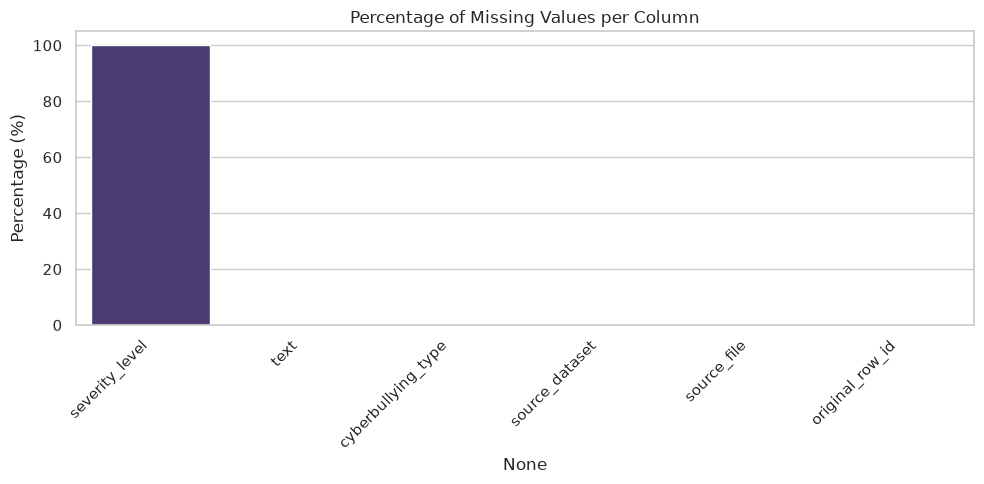

In [7]:
# 9. MISSING VALUE ANALYSIS

missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Missing Percentage', ascending=False)

print("Missing Value Analysis:")
display(missing_data)

# Visualize Missing Values
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_data.index, y=missing_data['Missing Percentage'], palette='viridis')
plt.title('Percentage of Missing Values per Column')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

In [8]:
# 10. DUPLICATE ANALYSIS

# 1. Exact duplicate rows
exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates} ({(exact_duplicates/len(df))*100:.2f}%)")

# 2. Duplicate text values (same text appearing multiple times)
if TEXT_COL in df.columns:
    duplicate_texts = df.duplicated(subset=[TEXT_COL]).sum()
    print(f"Duplicate texts: {duplicate_texts} ({(duplicate_texts/len(df))*100:.2f}%)")
    
    # 3. Conflicting labels (same text, different cyberbullying type)
    if TYPE_COL in df.columns:
        # Group by text and count unique cyberbullying types
        # Dropna so we don't count missing texts
        conflict_check = df.dropna(subset=[TEXT_COL]).groupby(TEXT_COL)[TYPE_COL].nunique()
        conflicting_texts = conflict_check[conflict_check > 1].count()
        print(f"Texts with conflicting {TYPE_COL} labels: {conflicting_texts}")
        
        if conflicting_texts > 0:
            print("\nExample of conflicting labels:")
            conflict_samples = conflict_check[conflict_check > 1].index[:2]
            display(df[df[TEXT_COL].isin(conflict_samples)].sort_values(by=TEXT_COL))

Exact duplicate rows: 0 (0.00%)
Duplicate texts: 2438 (5.54%)
Texts with conflicting cyberbullying_type labels: 1337

Example of conflicting labels:


,text,cyberbullying_type,severity_level,source_dataset,source_file,original_row_id
9470,""" Banyak orang menginginkan perubahan dalam hi...","['0', '0', '0', '0', '0', '0', '0', '0', '0', ...",NaN,indotoxic2024_annotated_data_v2_final,indotoxic2024_annotated_data_v2_final.csv,7070
9617,""" Banyak orang menginginkan perubahan dalam hi...","['0', '0', '0', '0', '0', '0', '0', '1', '0', ...",NaN,indotoxic2024_annotated_data_v2_final,indotoxic2024_annotated_data_v2_final.csv,7217
4553,"""Berpura-pura gila agar menjadi tidak gila.""","['0', '0']",NaN,indotoxic2024_annotated_data_v2_final,indotoxic2024_annotated_data_v2_final.csv,2153
20268,"""Berpura-pura gila agar menjadi tidak gila.""",['0'],NaN,indotoxic2024_annotated_data_v2_final,indotoxic2024_annotated_data_v2_final.csv,17868


In [9]:
# 11. LABEL AND CATEGORY ANALYSIS

def analyze_label_column(col_name):
    if col_name in df.columns:
        print(f"\nAnalysis for label: {col_name}")
        val_counts = df[col_name].value_counts(dropna=False)
        percentages = df[col_name].value_counts(dropna=False, normalize=True) * 100
        
        label_summary = pd.DataFrame({
            'Count': val_counts,
            'Percentage (%)': percentages
        })
        display(label_summary)
        
        # Check for potential casing/whitespace inconsistencies
        unique_vals = df[col_name].dropna().unique()
        suspicious = [v for v in unique_vals if str(v) != str(v).strip() or str(v) != str(v).lower()]
        if suspicious:
            print(f"WARNING: Potential inconsistencies (whitespace/casing) found in '{col_name}':")
            print(suspicious)
    else:
        print(f"Column '{col_name}' not found in dataset.")

analyze_label_column(TYPE_COL)
analyze_label_column(SEVERITY_COL)


Analysis for label: cyberbullying_type


,Count,Percentage (%)
cyberbullying_type,,
['0'],15059,34.211782
"['0', '0']",5955,13.528864
normal,5860,13.313038
hate_speech,5561,12.633755
insult,1748,3.971193
...,...,...
"['1', '0', '0', '0', '0']",1,0.002272
"['1', '0', '1', '1', '0']",1,0.002272
"['0', '0', '1', '0', '0']",1,0.002272



Analysis for label: severity_level


,Count,Percentage (%)
severity_level,,
NaN,44017,100.0


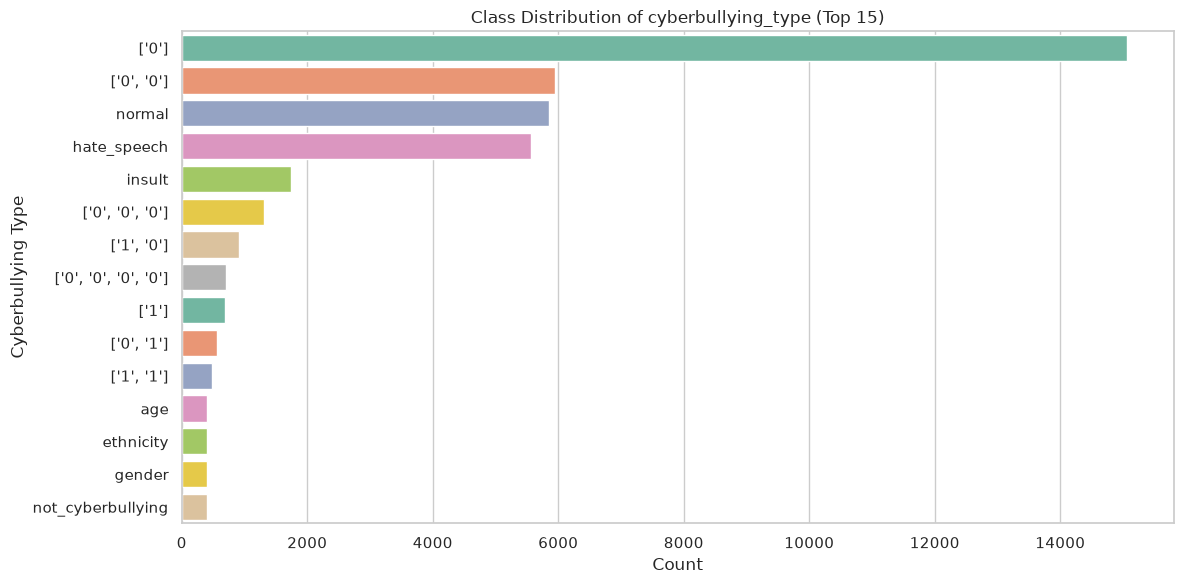

In [10]:
# 12. CLASS DISTRIBUTION

if TYPE_COL in df.columns:
    plt.figure(figsize=(12, 6))
    order = df[TYPE_COL].value_counts().iloc[:15].index
    sns.countplot(data=df, y=TYPE_COL, order=order, palette='Set2')
    plt.title(f'Class Distribution of {TYPE_COL} (Top 15)')
    plt.xlabel('Count')
    plt.ylabel('Cyberbullying Type')
    plt.tight_layout()
    plt.show()

if SEVERITY_COL in df.columns and not df[SEVERITY_COL].isnull().all():
    plt.figure(figsize=(10, 5))
    order = df[SEVERITY_COL].value_counts().iloc[:15].index
    sns.countplot(data=df, x=SEVERITY_COL, order=order, palette='Reds')
    plt.title(f'Class Distribution of {SEVERITY_COL} (Top 15)')
    plt.xlabel('Severity Level')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

In [11]:
# 13. TEXT CHARACTERISTICS

# Create temporary EDA features
if TEXT_COL in df.columns:
    # Fill NaN with empty string just for characteristic calculation
    temp_text = df[TEXT_COL].fillna("")
    
    df['char_count'] = temp_text.apply(len)
    df['word_count'] = temp_text.apply(lambda x: len(str(x).split()))
    df['punctuation_count'] = temp_text.apply(lambda x: len(re.findall(r'[^\w\s]', str(x))))
    
    print("Text Characteristics Descriptive Statistics:")
    display(df[['char_count', 'word_count', 'punctuation_count']].describe())
else:
    print(f"Text column '{TEXT_COL}' not found.")

Text Characteristics Descriptive Statistics:


,char_count,word_count,punctuation_count
count,44017.000000,44017.000000,44017.000000
mean,241.277188,34.566145,9.441579
std,429.504574,58.829494,21.625867
min,0.000000,0.000000,0.000000
25%,69.000000,11.000000,1.000000
50%,121.000000,18.000000,4.000000
75%,232.000000,33.000000,9.000000
max,4998.000000,880.000000,510.000000


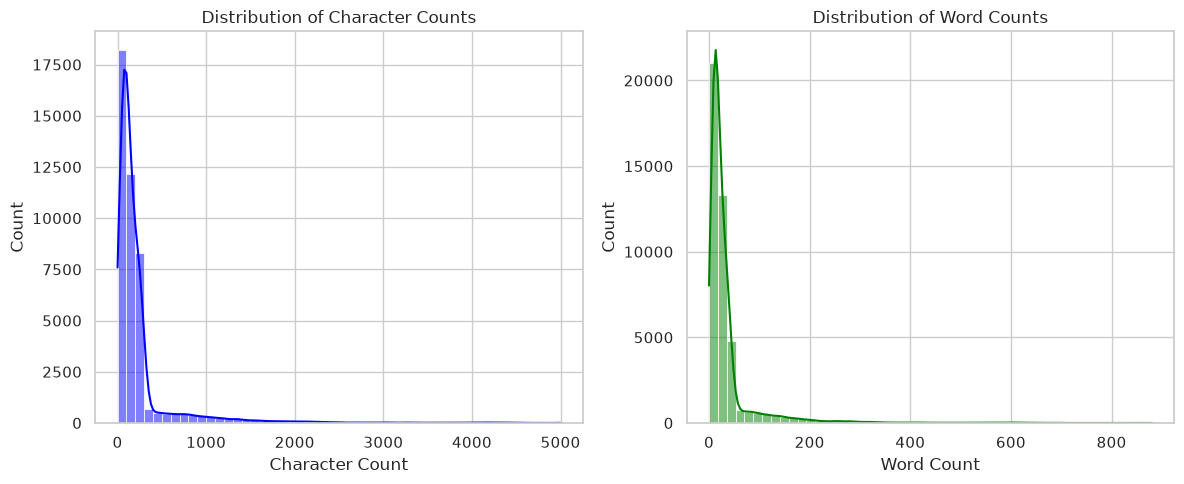

In [12]:
# 14. UNIVARIATE ANALYSIS

if 'word_count' in df.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df['char_count'], bins=50, kde=True, color='blue')
    plt.title('Distribution of Character Counts')
    plt.xlabel('Character Count')
    
    plt.subplot(1, 2, 2)
    sns.histplot(df['word_count'], bins=50, kde=True, color='green')
    plt.title('Distribution of Word Counts')
    plt.xlabel('Word Count')
    
    plt.tight_layout()
    plt.show()

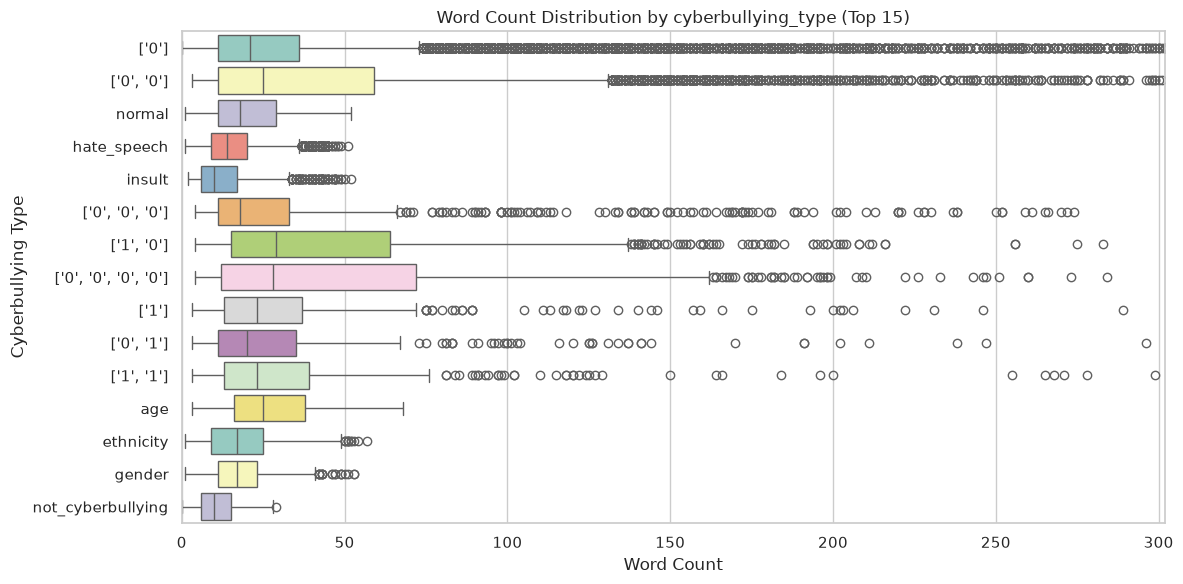

In [13]:
# 15. BIVARIATE ANALYSIS

if 'word_count' in df.columns and TYPE_COL in df.columns:
    plt.figure(figsize=(12, 6))
    top_15_labels = df[TYPE_COL].value_counts().iloc[:15].index
    df_filtered = df[df[TYPE_COL].isin(top_15_labels)]
    sns.boxplot(data=df_filtered, x='word_count', y=TYPE_COL, order=top_15_labels, palette='Set3')
    plt.title(f'Word Count Distribution by {TYPE_COL} (Top 15)')
    plt.xlabel('Word Count')
    plt.ylabel('Cyberbullying Type')
    plt.xlim(0, df['word_count'].quantile(0.99)) # Ignore extreme outliers for better visualization
    plt.tight_layout()
    plt.show()

Cross-tabulation: cyberbullying_type vs Source Dataset (Top 15 Labels)


cyberbullying_type,"['0', '0', '0', '0']","['0', '0', '0']","['0', '0']","['0', '1']",['0'],"['1', '0']","['1', '1']",['1'],age,ethnicity,gender,hate_speech,insult,normal,not_cyberbullying
source_dataset,,,,,,,,,,,,,,,
cyberbullying_cleaned_indo,0,0,0,0,0,0,0,0,400,400,400,0,0,0,400
data,0,0,0,0,0,0,0,0,0,0,0,5561,1748,5860,0
indotoxic2024_annotated_data_v2_final,698,1311,5955,561,15059,913,478,689,0,0,0,0,0,0,0


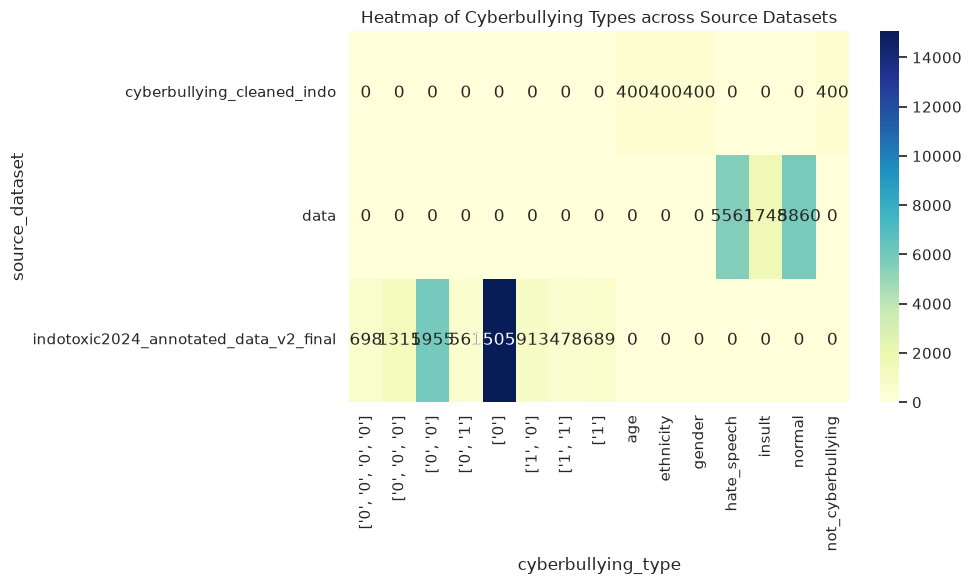

In [14]:
# 16. MULTIVARIATE ANALYSIS

if TYPE_COL in df.columns and 'source_dataset' in df.columns:
    top_15_labels = df[TYPE_COL].value_counts().iloc[:15].index
    df_filtered = df[df[TYPE_COL].isin(top_15_labels)]
    print(f"Cross-tabulation: {TYPE_COL} vs Source Dataset (Top 15 Labels)")
    cross_tab = pd.crosstab(df_filtered['source_dataset'], df_filtered[TYPE_COL])
    display(cross_tab)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
    plt.title('Heatmap of Cyberbullying Types across Source Datasets')
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for multivariate analysis are not available.")

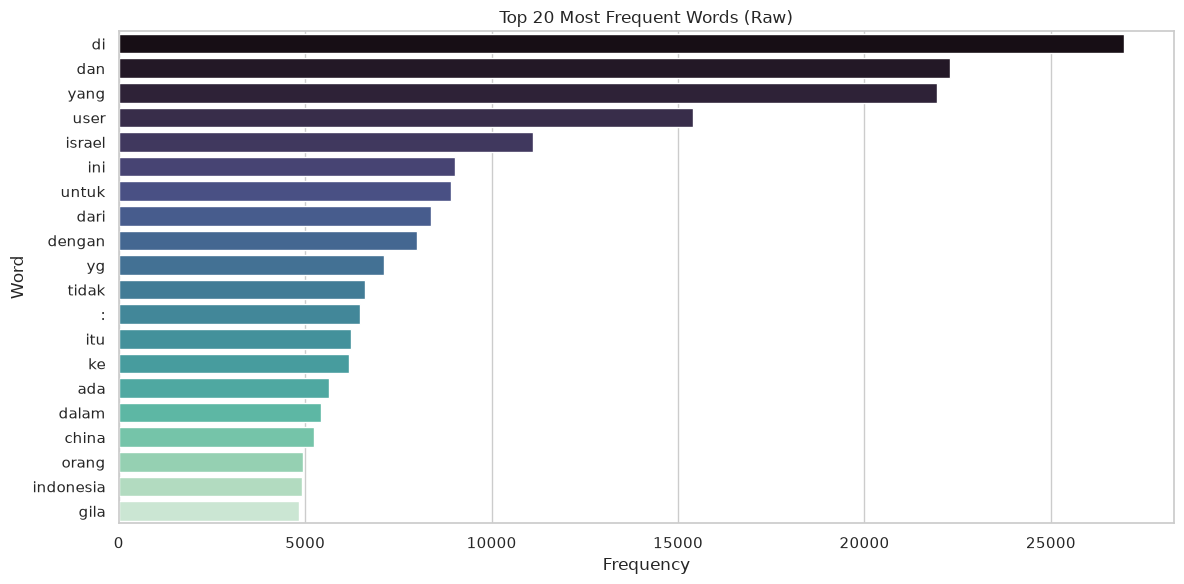

In [15]:
# 17. WORD FREQUENCY ANALYSIS

if TEXT_COL in df.columns:
    all_words = ' '.join(df[TEXT_COL].dropna().astype(str).str.lower()).split()
    word_freq = collections.Counter(all_words)
    
    most_common = word_freq.most_common(20)
    words, counts = zip(*most_common)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(counts), y=list(words), palette='mako')
    plt.title('Top 20 Most Frequent Words (Raw)')
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.tight_layout()
    plt.show()

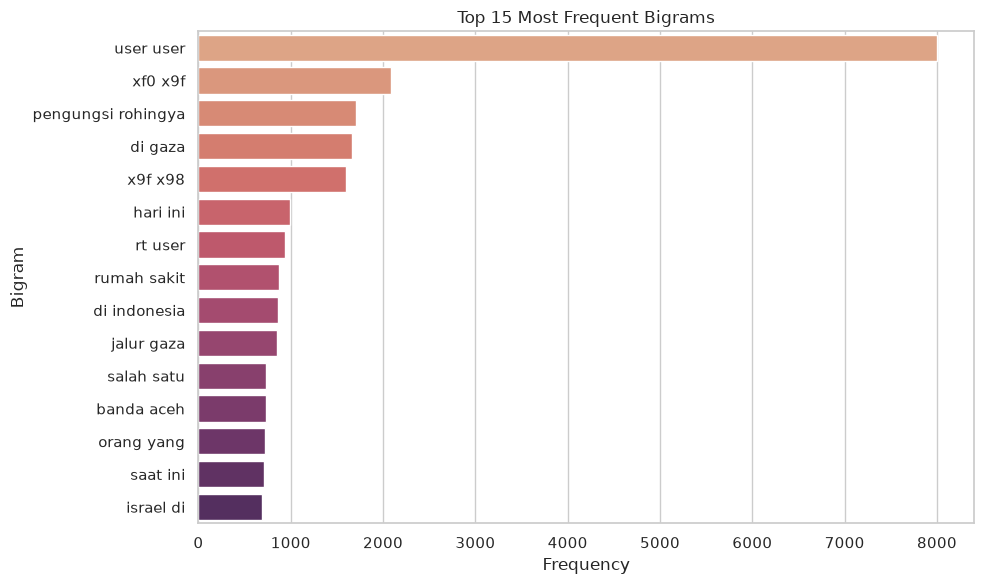

In [16]:
# 18. N-GRAM ANALYSIS

def get_top_ngrams(corpus, n, top_k=15):
    from sklearn.feature_extraction.text import CountVectorizer
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

if TEXT_COL in df.columns:
    try:
        corpus = df[TEXT_COL].dropna().astype(str).str.lower().tolist()
        top_bigrams = get_top_ngrams(corpus, 2)
        
        bigrams_df = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])
        plt.figure(figsize=(10, 6))
        sns.barplot(data=bigrams_df, x='Frequency', y='Bigram', palette='flare')
        plt.title('Top 15 Most Frequent Bigrams')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not perform N-Gram analysis: {e}")

In [17]:
# 19. TEXT ANOMALY AND OUTLIER ANALYSIS

print("Text data does not have traditional numerical outliers in the same way as tabular data.")
print("Outlier analysis for text is performed based on text characteristics (e.g., extremely short/long texts).")

if 'word_count' in df.columns:
    very_short = df[df['word_count'] < 3]
    print(f"\nRecords with < 3 words: {len(very_short)}")
    if len(very_short) > 0:
        display(very_short[[TEXT_COL, 'word_count']].head())
        
    extremely_long = df[df['word_count'] > df['word_count'].quantile(0.99)]
    print(f"\nRecords in the top 1% of word counts (>{df['word_count'].quantile(0.99):.0f} words): {len(extremely_long)}")
    if len(extremely_long) > 0:
        display(extremely_long[[TEXT_COL, 'word_count']].head())

Text data does not have traditional numerical outliers in the same way as tabular data.
Outlier analysis for text is performed based on text characteristics (e.g., extremely short/long texts).

Records with < 3 words: 164


,text,word_count
425,hapus hidupmu,2
532,hahahaaa thelma,2
563,kau bodoh,2
707,rt,1
846,aku diblokir,2



Records in the top 1% of word counts (>302 words): 435


,text,word_count
2562,Badan Meteorologi Klimatologi dan Geofisika (B...,324
2565,PT Kereta Cepat Indonesia China (KCIC) menamba...,336
2611,Beberapa waktu lalu menyebar kabar heboh di Ch...,316
2613,Bakal calon presiden Ganjar Pranowo resmi meng...,410
2635,POLITIK AKAL SEHAT DAN JUNJUNG NORMA NURANI NE...,500


In [18]:
# 20. DATA INCONSISTENCY ANALYSIS

inconsistencies = []

if df[TEXT_COL].isnull().sum() > 0:
    inconsistencies.append({
        'Issue': 'Missing Text',
        'Count': df[TEXT_COL].isnull().sum(),
        'Recommended Next Step': 'Remove rows with missing text in preprocessing.'
    })
    
if df[TYPE_COL].isnull().sum() > 0:
    inconsistencies.append({
        'Issue': f'Missing {TYPE_COL}',
        'Count': df[TYPE_COL].isnull().sum(),
        'Recommended Next Step': 'Identify source and decide to drop or manually relabel.'
    })
    
if 'conflicting_texts' in locals() and conflicting_texts > 0:
    inconsistencies.append({
        'Issue': 'Conflicting Labels for same Text',
        'Count': conflicting_texts,
        'Recommended Next Step': 'Resolve conflicts during the Validation stage.'
    })
    
if len(inconsistencies) > 0:
    df_inconsistencies = pd.DataFrame(inconsistencies)
    display(df_inconsistencies)
else:
    print("No major inconsistencies automatically detected.")

,Issue,Count,Recommended Next Step
0,Missing Text,10,Remove rows with missing text in preprocessing.
1,Conflicting Labels for same Text,1337,Resolve conflicts during the Validation stage.


# 21. FIVE KEY INSIGHTS

*(To be filled by the researcher based on the actual analysis generated above)*

1. **Dataset Size Insight**: The merged dataset contains X records, but Y% of texts are missing.
2. **Class Imbalance Insight**: The `cyberbullying_type` is heavily skewed towards class Z, requiring mitigation (e.g., SMOTE/undersampling) before training.
3. **Missing Severity Labels Insight**: The `severity_level` column is completely empty for dataset A, indicating that relabeling is necessary.
4. **Text Length Insight**: The median word count is X, but there are Y anomalies with < 3 words which may not contain enough semantic meaning for TF-IDF.
5. **Label Conflicts Insight**: There are X duplicate texts that possess conflicting labels, requiring manual intervention in the validation stage.

# 22. EDA SUMMARY

### Dataset Overview
- **Number of records**: *(Check Step 6)*
- **Text column**: `text`
- **Target columns**: `cyberbullying_type`, `severity_level`

### Data Quality
- Analyzed missing values and duplicates.
- Investigated label consistency and casing.

### Recommendations for Next Steps
- **notebooks/03_relabeling.ipynb**: Standardize the inconsistent `cyberbullying_type` labels to match the 5 target classes (`normal`, `insult`, `harassment`, `threat`, `hate_speech`). Impute missing severity levels if possible.
- **notebooks/04_validation.ipynb**: Resolve conflicting labels identified in Step 10.
- **notebooks/05_preprocessing.ipynb**: Remove missing text rows and extremely short anomalous texts identified in Step 19. Clean out punctuation and lowercase the text.

In [19]:
# 23. EXPORT EDA ARTIFACTS

# Export descriptive stats
stats_out = REPORTS_DIR / "text_statistics.csv"
if 'word_count' in df.columns:
    df[['char_count', 'word_count', 'punctuation_count']].describe().to_csv(stats_out)
    print(f"Exported text statistics to {stats_out}")

# Export Inconsistency Analysis if exists
issues_out = REPORTS_DIR / "data_quality_issues.csv"
if len(inconsistencies) > 0:
    df_inconsistencies.to_csv(issues_out, index=False)
    print(f"Exported quality issues to {issues_out}")

print("\nEDA Artifact generation complete.")

Exported text statistics to /home/zapp/Kampus/PM-NEW/reports/text_statistics.csv
Exported quality issues to /home/zapp/Kampus/PM-NEW/reports/data_quality_issues.csv

EDA Artifact generation complete.


# 24. HOW TO RUN THIS NOTEBOOK

1. Activate the project's virtual environment.
2. Ensure that the merged dataset exists in: `data/merged/merged_cyberbullying_dataset.csv`
3. Open this notebook (`notebooks/02_eda.ipynb`) in Jupyter Lab or VS Code.
4. Verify the configured input dataset path in **Step 4**.
5. Run the notebook from the first cell to the last cell.
6. Review the generated visualizations and data quality findings.
7. Fill out the "Five Key Insights" section based on the output you observe.
8. Review the generated artifacts in: `reports/`
9. Use these findings to prepare the rules for the next stage: `notebooks/03_relabeling.ipynb`